<a href="https://colab.research.google.com/github/RamMohanHota/ML-and-PYTHON-LAB/blob/main/_06_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
print(df.dtypes)

survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object


In [4]:
print(df.nunique())

survived         2
pclass           3
sex              2
age             88
sibsp            7
parch            7
fare           248
embarked         3
class            3
who              3
adult_male       2
deck             7
embark_town      3
alive            2
alone            2
dtype: int64


In [5]:
#variable count
print(df.count())


survived       891
pclass         891
sex            891
age            714
sibsp          891
parch          891
fare           891
embarked       889
class          891
who            891
adult_male     891
deck           203
embark_town    889
alive          891
alone          891
dtype: int64


In [6]:
missing = df.isnull().sum()
print(missing[missing >0])

age            177
embarked         2
deck           688
embark_town      2
dtype: int64


In [7]:
display(df.describe(include=[np.number]).T)
display(df.describe(include=['object','category','bool']).T)

,count,mean,std,min,25%,50%,75%,max
survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
sibsp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


,count,unique,top,freq
sex,891,2,male,577
embarked,889,3,S,644
class,891,3,Third,491
who,891,3,man,537
adult_male,891,2,True,537
deck,203,7,C,59
embark_town,889,3,Southampton,644
alive,891,2,no,549
alone,891,2,True,537


In [8]:
target_column='survived'
print("\n numeric feature:")
numeric_cols=df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols=[col for col in numeric_cols if col!=target_column]
print(numeric_cols)
print("\n categorical feature:")
categorical_cols=df.select_dtypes(include=['object','category','bool']).columns.tolist()
print(categorical_cols)
print(target_column)


 numeric feature:
['pclass', 'age', 'sibsp', 'parch', 'fare']

 categorical feature:
['sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']
survived


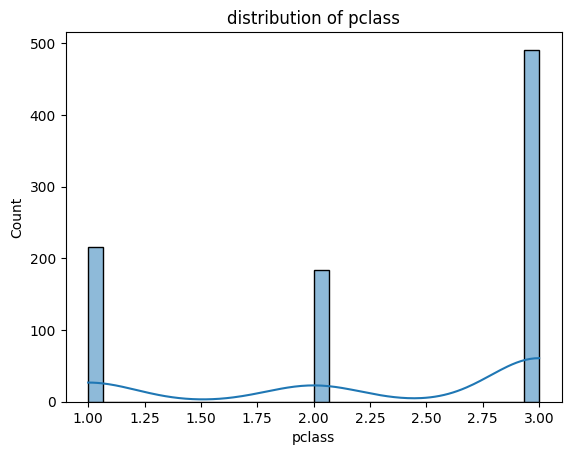

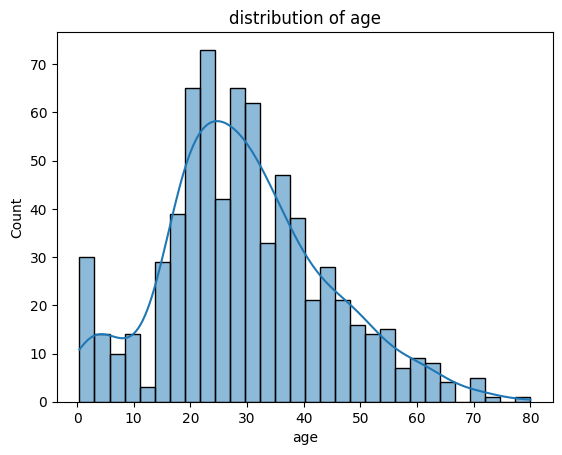

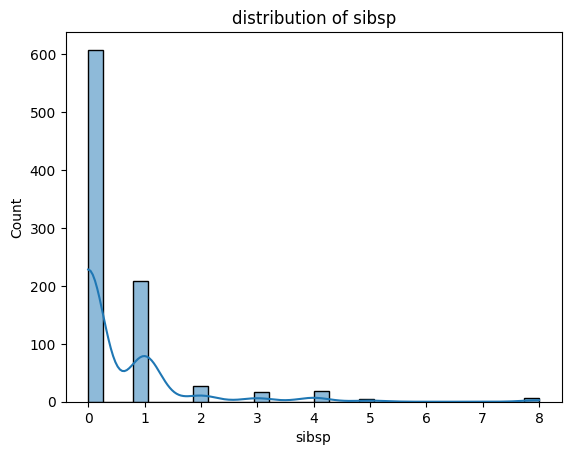

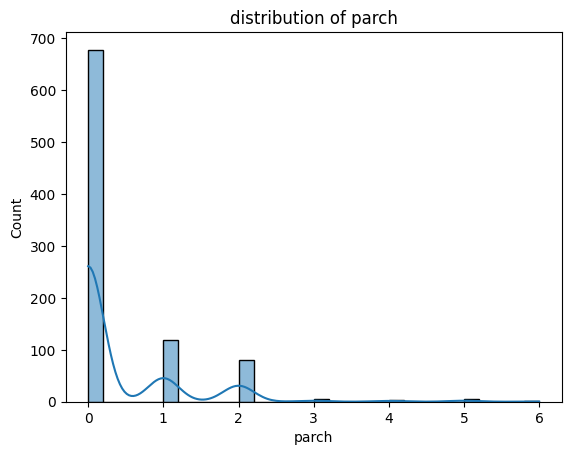

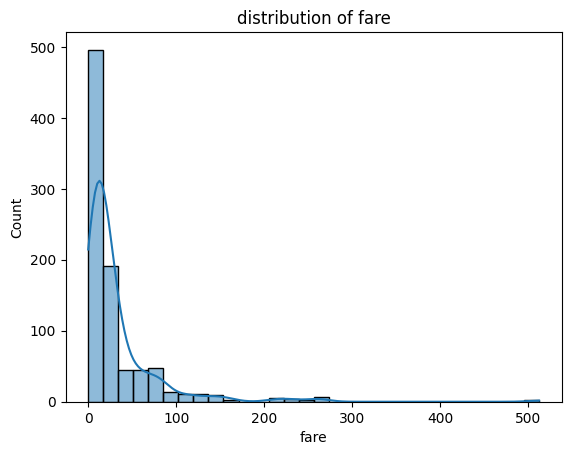

In [9]:
for col in numeric_cols:
  sns.histplot(df[col],kde=True,bins=30)
  plt.title(f"distribution of {col}")
  plt.show()

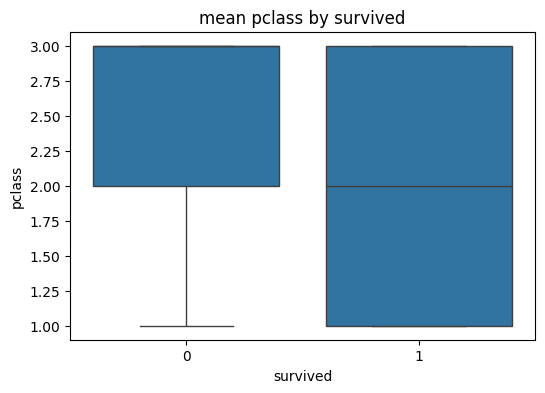

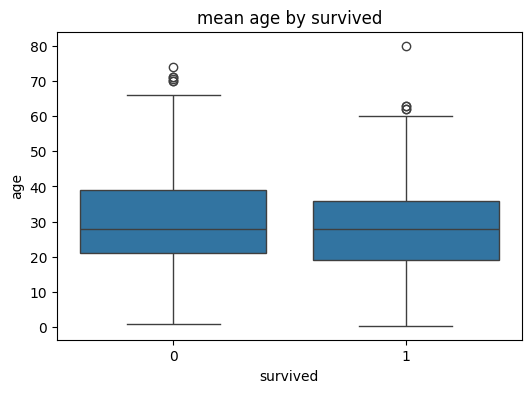

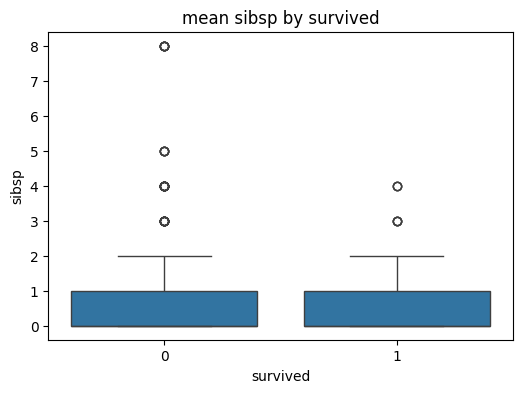

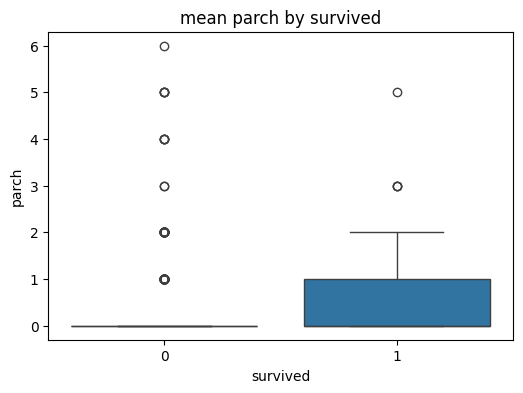

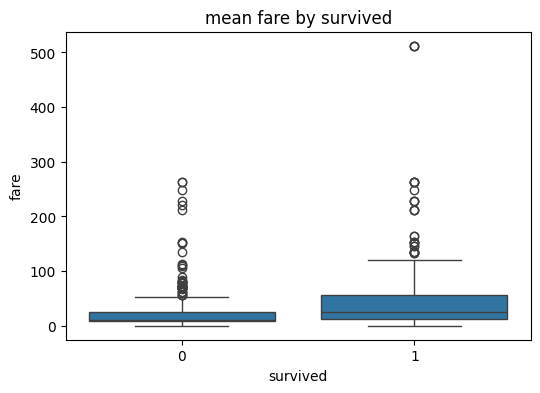

In [10]:
for col in numeric_cols:
  plt.figure(figsize=(6,4))
  sns.boxplot(x=target_column,y=col,data=df)
  plt.title(f"mean {col} by {target_column}")
  plt.show()


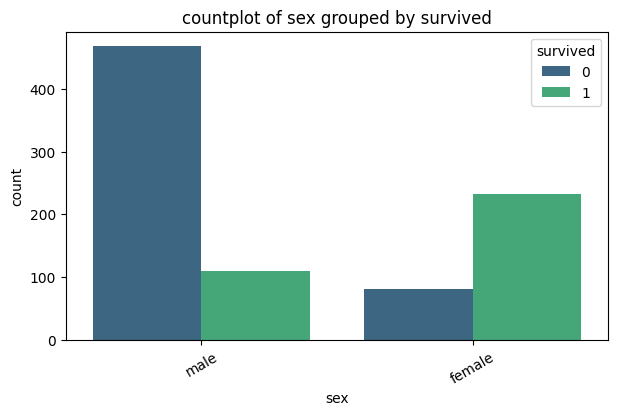

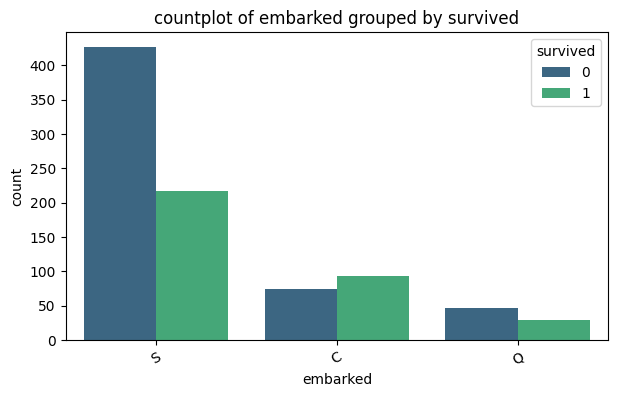

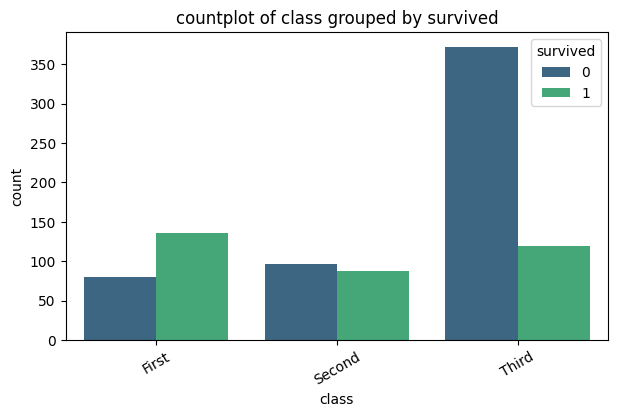

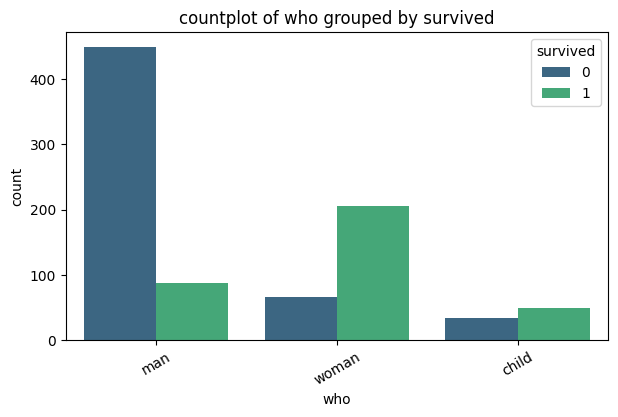

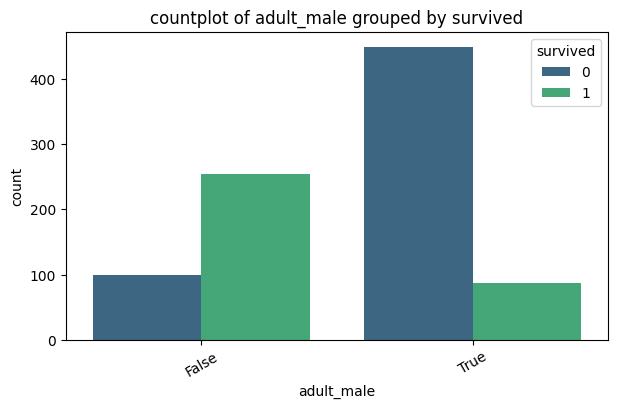

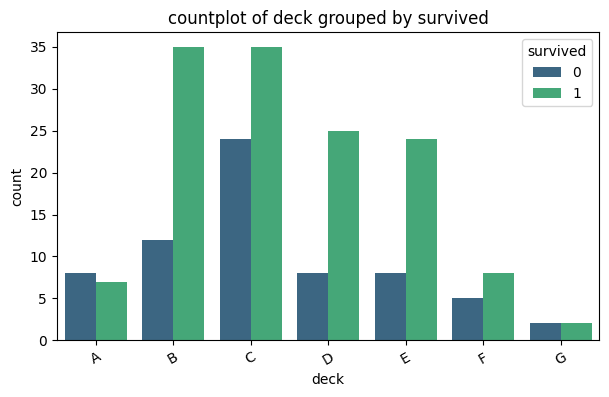

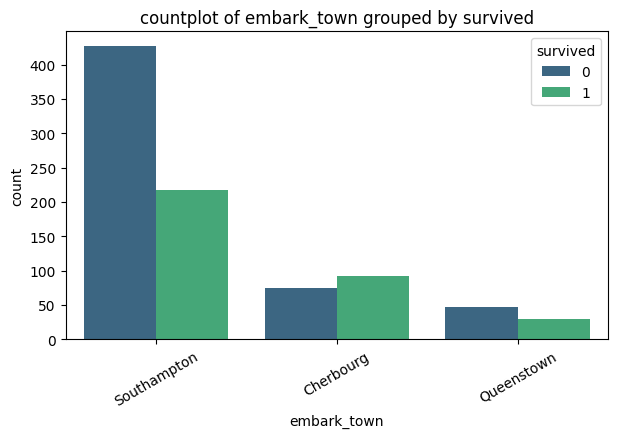

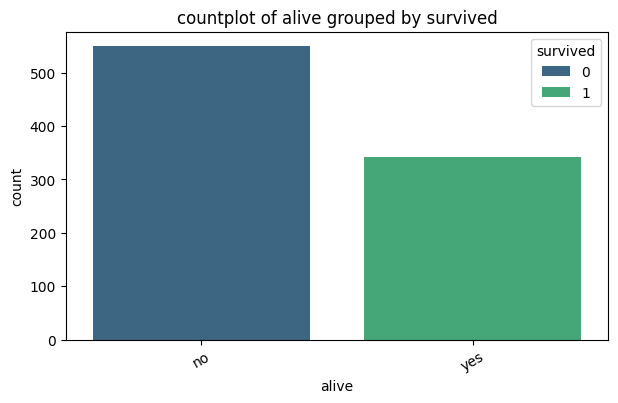

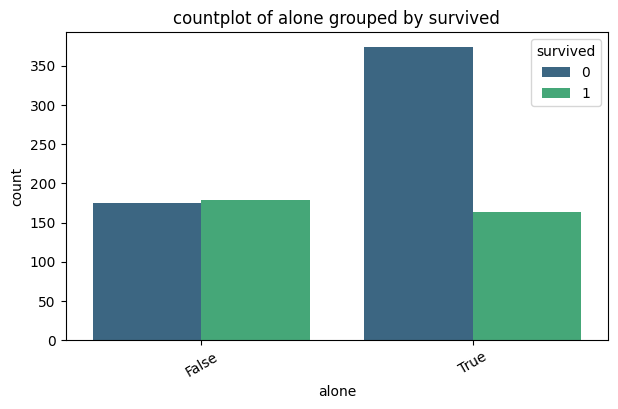

In [11]:
for col in categorical_cols:
  plt.figure(figsize=(7,4))
  sns.countplot(x=col,hue=target_column,data=df,palette="viridis")
  plt.title(f"countplot of {col} grouped by {target_column}")
  plt.xticks(rotation=30)
  plt.show()

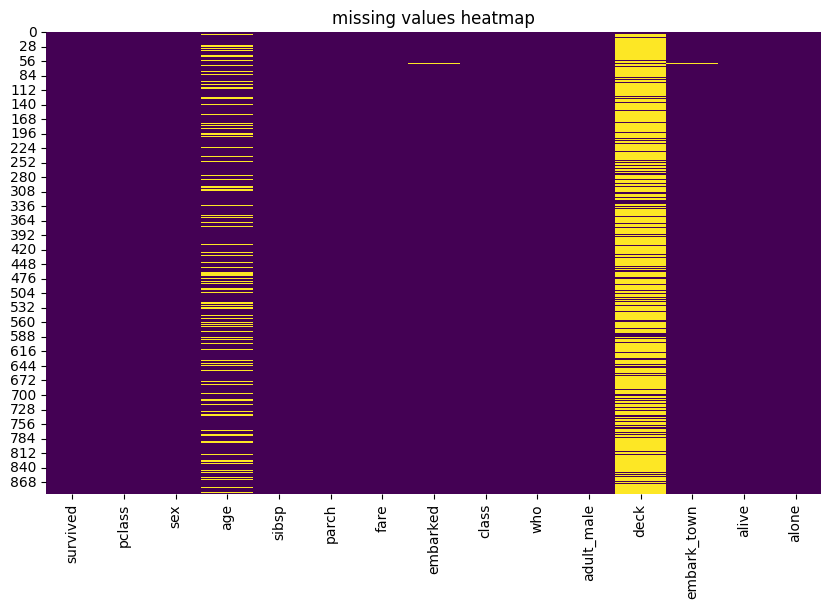

In [12]:
# missing heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(),cbar=False,cmap='viridis')
plt.title("missing values heatmap")
plt.show()

In [13]:
from functools import update_wrapper
print("\n removing outliers using IQR method:")
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

df_no_outliers_ipr = df[~((df[numeric_cols] < lower_bound) | (df[numeric_cols] > upper_bound)).any(axis=1)]

print(f"original shape: {df.shape}")
print(f"shape after removing outliers: {df_no_outliers_ipr.shape}")


 removing outliers using IQR method:
original shape: (891, 15)
shape after removing outliers: (598, 15)


In [14]:
target_column='survived'
print("\n numeric feature:")
numeric_cols=df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols=[col for col in numeric_cols if col!=target_column]
print(numeric_cols)
print("\n categorical feature:")
categorical_cols=df.select_dtypes(include=['object','category','bool']).columns.tolist()
print(categorical_cols)
print(target_column)


 numeric feature:
['pclass', 'age', 'sibsp', 'parch', 'fare']

 categorical feature:
['sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']
survived


In [15]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoders = {}
for col in categorical_cols:
    label_encoders[col] = LabelEncoder()
    df[col] = label_encoders[col].fit_transform(df[col])

print("DataFrame after Label Encoding:")
display(df.head())

DataFrame after Label Encoding:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,2,1,1,7,2,0,0
1,1,1,0,38.0,1,0,71.2833,0,0,2,0,2,0,1,0
2,1,3,0,26.0,0,0,7.9250,2,2,2,0,7,2,1,1
3,1,1,0,35.0,1,0,53.1000,2,0,2,0,2,2,1,0
4,0,3,1,35.0,0,0,8.0500,2,2,1,1,7,2,0,1


In [16]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Apply StandardScaler to numeric columns
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print("DataFrame after Standard Scaling:")
display(df.head())

DataFrame after Standard Scaling:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,0.827377,1,-0.530377,0.432793,-0.473674,-0.502445,2,2,1,1,7,2,0,0
1,1,-1.566107,0,0.571831,0.432793,-0.473674,0.786845,0,0,2,0,2,0,1,0
2,1,0.827377,0,-0.254825,-0.474545,-0.473674,-0.488854,2,2,2,0,7,2,1,1
3,1,-1.566107,0,0.365167,0.432793,-0.473674,0.420730,2,0,2,0,2,2,1,0
4,0,0.827377,1,0.365167,-0.474545,-0.473674,-0.486337,2,2,1,1,7,2,0,1


In [17]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
print("dataframe after scalling:")
print(df.head())



dataframe after scalling:
   survived  pclass  sex       age  sibsp  parch      fare  embarked  class  \
0         0     1.0    1  0.271174  0.125    0.0  0.014151         2      2   
1         1     0.0    0  0.472229  0.125    0.0  0.139136         0      0   
2         1     1.0    0  0.321438  0.000    0.0  0.015469         2      2   
3         1     0.0    0  0.434531  0.125    0.0  0.103644         2      0   
4         0     1.0    1  0.434531  0.000    0.0  0.015713         2      2   

   who  adult_male  deck  embark_town  alive  alone  
0    1           1     7            2      0      0  
1    2           0     2            0      1      0  
2    2           0     7            2      1      1  
3    2           0     2            2      1      0  
4    1           1     7            2      0      1  
